<a href="https://colab.research.google.com/github/fancesatria/homograph_cyrilic_url_detection/blob/main/homograph_cyryclic_url_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Dataset Preprocessing

In [ ]:
import gdown

gdown.download("https://drive.google.com/uc?id=1wop4B_FhcGKNbq1fks6Ee4eDXghiumY4", "tranco.csv", quiet=False)
gdown.download("https://drive.google.com/uc?id=1eHdp6QSwcuhiDT0w5FoQ9yUO74M5nkLd", "phistank.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1wop4B_FhcGKNbq1fks6Ee4eDXghiumY4
To: /content/tranco.csv
100%|██████████| 22.7M/22.7M [00:00<00:00, 148MB/s]
Downloading...
From: https://drive.google.com/uc?id=1eHdp6QSwcuhiDT0w5FoQ9yUO74M5nkLd
To: /content/phistank.csv
100%|██████████| 11.3M/11.3M [00:00<00:00, 71.4MB/s]


'phistank.csv'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tranco = pd.read_csv("tranco.csv", header=None, names=['rank', 'domain'])
phish = pd.read_csv("phistank.csv")

print(tranco.head())
print(phish.head())

   rank            domain
0     1        google.com
1     2  gtld-servers.net
2     3       gstatic.com
3     4      facebook.com
4     5    cloudflare.com
   phish_id                                             url  \
0   9407954         https://suites-en.wixstudio.com/live-en   
1   9407953  https://appsuite-treixo.wixstudio.com/en-suite   
2   9407952    https://suites-io-trexer.wixstudio.com/en-us   
3   9407951  https://trexer-appsuite.wixstudio.com/logon-en   
4   9407950          https://appsuiteen.wixstudio.com/en-us   

                                    phish_detail_url  \
0  http://www.phishtank.com/phish_detail.php?phis...   
1  http://www.phishtank.com/phish_detail.php?phis...   
2  http://www.phishtank.com/phish_detail.php?phis...   
3  http://www.phishtank.com/phish_detail.php?phis...   
4  http://www.phishtank.com/phish_detail.php?phis...   

             submission_time verified          verification_time online target  
0  2026-04-29T05:55:33+00:00      yes  2026-04-

In [ ]:
print("Tranco:\n")
print(tranco.info())

print("\nPhish:\n")
print(phish.info())

Tranco:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   rank    1000000 non-null  int64 
 1   domain  1000000 non-null  object
dtypes: int64(1), object(1)
memory usage: 15.3+ MB
None

Phish:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58347 entries, 0 to 58346
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   phish_id           58347 non-null  int64 
 1   url                58347 non-null  object
 2   phish_detail_url   58347 non-null  object
 3   submission_time    58347 non-null  object
 4   verified           58347 non-null  object
 5   verification_time  58347 non-null  object
 6   online             58347 non-null  object
 7   target             58347 non-null  object
dtypes: int64(1), object(7)
memory usage: 3.6+ MB
None


In [ ]:
# Cleaning URL
import re

def clean_url(url):
  url = str(url).lower()
  url = re.sub(r'https?://', '', url)
  url = re.sub(r'www\.', '', url)
  return url.strip('/')

tranco_clean = tranco['domain'].dropna().apply(clean_url)
phish_clean = phish['url'].dropna().apply(clean_url)

In [ ]:
# Take Domain (Because homograph attack is in domain)
from urllib.parse import urlparse

def extract_domain(url):
  parsed = urlparse("http://"+ url)
  return parsed.netloc

phish_domains = phish_clean.apply(extract_domain)

In [ ]:
# Remove duplicate
tranco_clean = tranco_clean.drop_duplicates()
phish_domains = phish_domains.drop_duplicates()

In [ ]:
# Count check
print("Legit:", len(tranco_clean))
print("Phishing:", len(phish_domains))

Legit: 1000000
Phishing: 27105


In [ ]:
# Balancing
import random
import numpy as np

random.seed(42)
np.random.seed(42)

N = 25000
tranco_sample = random.sample(list(tranco_clean), N)
phish_sample = random.sample(list(phish_domains), N)

In [ ]:
print("Legit:", len(tranco_sample))
print("Phishing:", len(phish_sample))

Legit: 25000
Phishing: 25000


In [ ]:
# Generate homograph
homoglyph_map = {
    'a': ['а'],
    'e': ['е'],
    'o': ['о'],
    'i': ['і'],
    'c': ['с'],
    'p': ['р'],
    'x': ['х'],
    'l': ['ӏ']
}

def generate_homograph(domain):
  chars = list(domain)
  positions = [
      i for i, c in enumerate(chars) if c.lower() in homoglyph_map
  ]

  if not positions:
    return domain

  replace_n = min(len(positions), random.randint(1, 2))
  selected = random.sample(positions, replace_n)

  for pos in selected:
    chars[pos] = random.choice(homoglyph_map[chars[pos]])

  return ''.join(chars)

homograph_sample = [generate_homograph(d) for d in tranco_sample]

# Validate change
for i in range(10):
    print(tranco_sample[i], "→", homograph_sample[i])

rceth.by → rсеth.by
moonofalabama.org → mоonofalabama.org
thepennyhoarder.com → thepеnnyhоarder.com
factorydeportivo.com.ar → factorydepоrtivo.com.аr
board-game.co.uk → board-game.cо.uk
jma-tradeshow.com → jmа-tradeshow.cоm
iluchanyn.com → iluсhanyn.com
astral-projection.info → astral-projection.іnfo
discounttirecenters.com → discounttirеcenters.com
foxentry.com → foхentry.cоm


In [ ]:
# Build final dataset
df_legit = pd.DataFrame({
    'url': tranco_sample,
    'label': 0,
    'type': 'legitimate'
})

df_phish = pd.DataFrame({
    'url': phish_sample,
    'label': 1,
    'type': 'phishing'
})

df_homo = pd.DataFrame({
    'url': homograph_sample,
    'label': 2,
    'type': 'homograph'
})

In [ ]:
# Join data
df = pd.concat([df_legit, df_phish, df_homo], ignore_index=True)
df = df.sample(frac=1).reset_index(drop=True)

In [ ]:
# Validate dataset
print(df['type'].value_counts())
print(df['label'].value_counts())

type
phishing      25000
legitimate    25000
homograph     25000
Name: count, dtype: int64
label
1    25000
0    25000
2    25000
Name: count, dtype: int64


# 2. Feature Engineering

In [ ]:
import string
import math
from collections import Counter

df['length'] = df['url'].apply(len)
df['num_digits'] = df['url'].apply(lambda x: sum(c.isdigit() for c in x))
special_chars = set(string.punctuation)

# special char
df['num_special'] = df['url'].apply(
    lambda x: sum(c in special_chars for c in x)
)

# entropy
def shannon_entropy(text):
  prob = [n / len(text) for n in Counter(text).values()]
  return -sum(p * math.log2(p) for p in prob)
df['entropy'] = df['url'].apply(shannon_entropy)

# punycode detection
df['is_punycode'] = df['url'].apply(lambda x: int('xn--' in x))

# non ascii chars
def has_non_ascii(text):
  return int(any(ord(c) > 127 for c in text))
df['non_ascii'] = df['url'].apply(has_non_ascii)

# script mixing
def script_mixing(text):
    latin = any('a' <= c <= 'z' for c in text)
    non_latin = any(ord(c) > 127 for c in text)
    return int(latin and non_latin)
df['script_mixing'] = df['url'].apply(script_mixing)

# subdomain
df['num_dots'] = df['url'].apply(lambda x: x.count('.'))

# tld len
def tld_length(domain):
  parts = domain.split('.')
  return len(parts[-1]) if len(parts) > 1 else 0
df['tld_length'] = df['url'].apply(tld_length)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   url            75000 non-null  object 
 1   label          75000 non-null  int64  
 2   type           75000 non-null  object 
 3   length         75000 non-null  int64  
 4   num_digits     75000 non-null  int64  
 5   num_special    75000 non-null  int64  
 6   entropy        75000 non-null  float64
 7   is_punycode    75000 non-null  int64  
 8   non_ascii      75000 non-null  int64  
 9   script_mixing  75000 non-null  int64  
 10  num_dots       75000 non-null  int64  
 11  tld_length     75000 non-null  int64  
dtypes: float64(1), int64(9), object(2)
memory usage: 6.9+ MB


# 3. Visualization

/tmp/ipykernel_727/527739938.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='Set2')


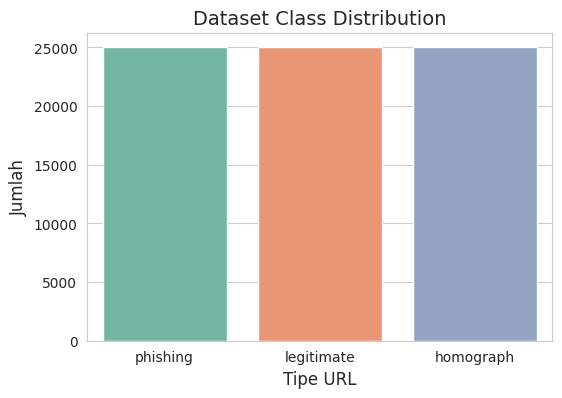

In [ ]:
# Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='type', data=df, palette='Set2')
plt.title('Dataset Class Distribution', fontsize=14)
plt.xlabel('Tipe URL', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.show()

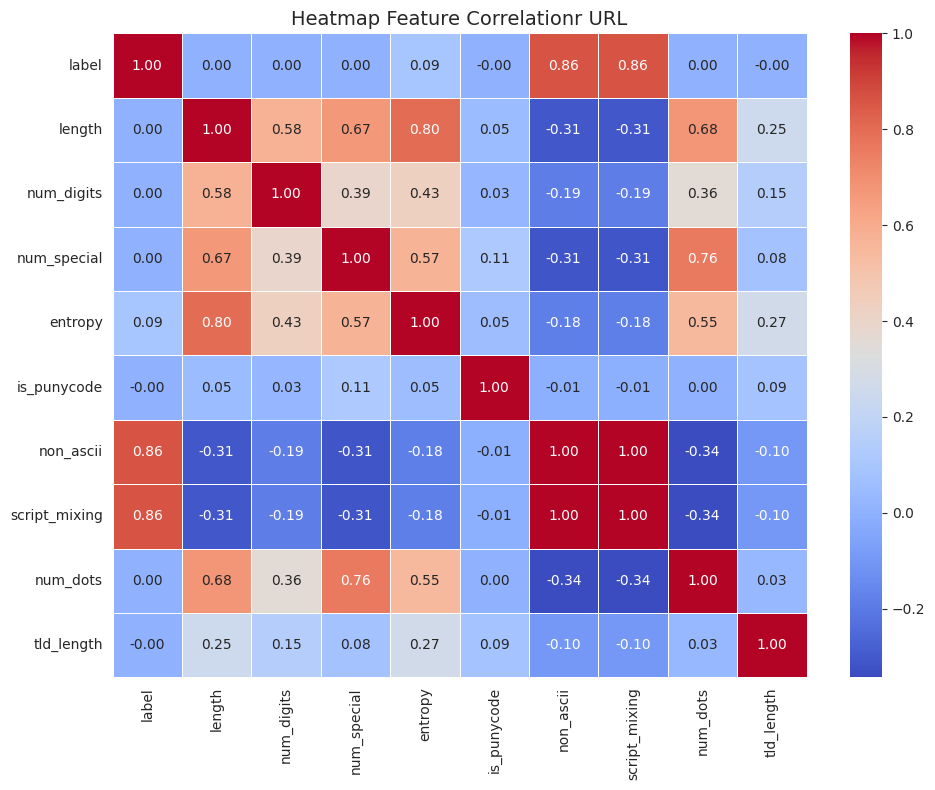

In [ ]:
# Heatmap
plt.figure(figsize=(10, 8))
numeric_df = df.drop(['url', 'type'], axis=1)

correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={"size": 10})
plt.title('Heatmap Feature Correlationr URL', fontsize=14)
plt.tight_layout()
plt.show()

# 4. Handle Multicolinearity

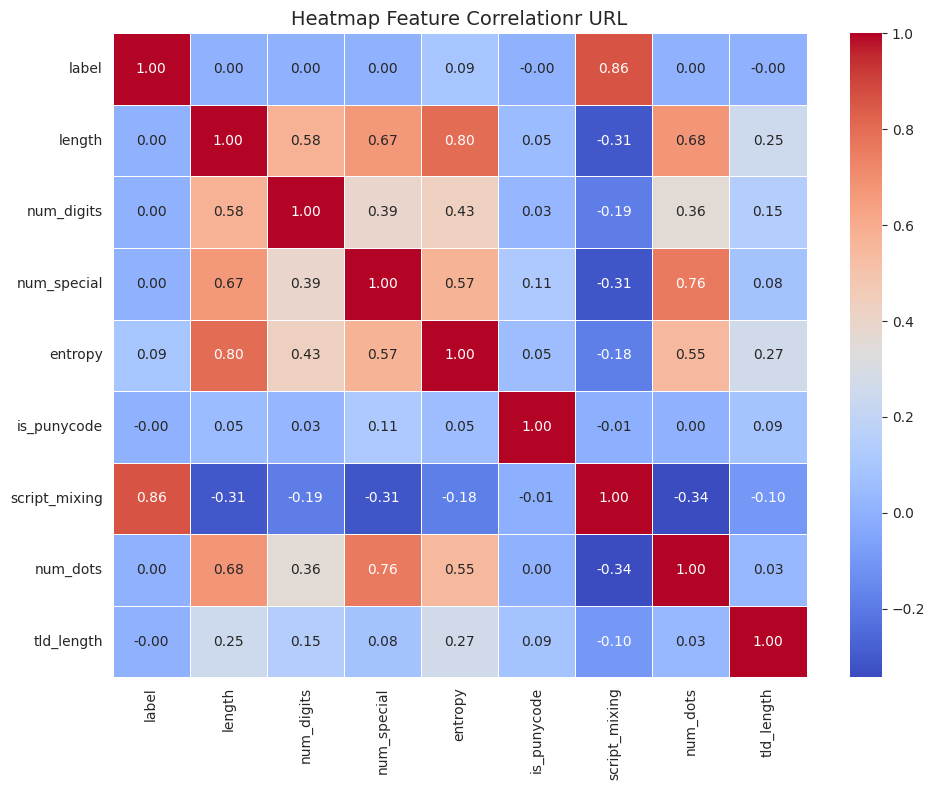

In [ ]:
df = df.drop(columns=['non_ascii'])

plt.figure(figsize=(10, 8))
numeric_df = df.drop(['url', 'type'], axis=1)

correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={"size": 10})
plt.title('Heatmap Feature Correlationr URL', fontsize=14)
plt.tight_layout()
plt.show()

# 5. Split Data

In [ ]:
from sklearn.model_selection import train_test_split
import hashlib

y = df['label']
X_idx = df.index

train_idx, test_idx = train_test_split(
    X_idx, test_size=0.2, random_state=42, stratify=y
)

# Full Features
X = df.drop(['url', 'label', 'type'], axis=1)
X_train = X.loc[train_idx]
X_test = X.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

# Basic
features_basic = [
    'length',
    'num_digits',
    'num_special',
    'num_dots',
    'tld_length'
]
X_basic = X[features_basic]

X_basic_train = X_basic.loc[train_idx]
X_basic_test = X_basic.loc[test_idx]
y_basic_train = y.loc[train_idx]
y_basic_test = y.loc[test_idx]

# Hash
def hash_vector(url):
  h = hashlib.sha256(url.encode()).digest()
  return list(h)
hash_features = df['url'].apply(hash_vector)
X_hash = pd.DataFrame(hash_features.tolist(), index=df.index)
X_hash.columns = X_hash.columns.astype(str)

X_bh = pd.concat([X_basic, X_hash], axis=1)

X_bh_train = X_bh.loc[train_idx]
X_bh_test = X_bh.loc[test_idx]
y_bh_train = y.loc[train_idx]
y_bh_test = y.loc[test_idx]


# 6. Modelling

In [ ]:
pip install catboost

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix

In [ ]:
results = []

def evaluate_model(name, y_test, y_pred, results):
  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred, average='macro')
  rec = recall_score(y_test, y_pred, average='macro')
  f1 = f1_score(y_test, y_pred, average='macro')

  results.append({
      'Model': name,
      'Accuracy': round(acc, 5),
      'Precision': round(prec, 5),
      'Recall': round(rec, 5),
      'F1 Score': round(f1, 5)
  })


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legitimate (0)', 'Phishing (1)', 'Homograph (2)'],
                yticklabels=['Legitimate (0)', 'Phishing (1)', 'Homograph (2)'])

    plt.title(title, fontsize=14, pad=15)
    plt.ylabel('Actual Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_feature_importance(model, feature_names, title="Feature Importance"):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'get_feature_importance'):
        importances = model.get_feature_importance()
    else:
        print("This model is not supported for check feature importance directly")
        return

    feat_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

    # Plotting
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')

    plt.title(title, fontsize=14, pad=15)
    plt.xlabel('Relative Importance', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.show()

def tune_model(model, param_grid, X_train, y_train, method="random"):
  search = RandomizedSearchCV(
        model,
        param_distributions=param_grid,
        n_iter=10,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

  search.fit(X_train, y_train)

  print("Best Params:", search.best_params_)
  print("Best Score:", search.best_score_)

  return search.best_estimator_

def run_model(model, name, X_train, y_train, X_test, y_test, results, param_grid=None, tuning=False):
  if tuning and param_grid is not None:
    model = tune_model(model, param_grid, X_train, y_train)
    name = name + "-Tuned"
  else:
    name = name + "-No tuning"

  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  evaluate_model(name, y_test, y_pred, results)
  return model, y_pred


## A. Hash

In [ ]:
# 1. Logistic Regression
lr_basic = LogisticRegression(max_iter=1000)
run_model(lr_basic, "Logistic Regression (Hash)", X_bh_train, y_bh_train, X_bh_test, y_bh_test, results)

# 2. Random Forest
rf_basic = RandomForestClassifier(n_estimators=100)
run_model(rf_basic, "Random Forest (Hash)", X_bh_train, y_bh_train, X_bh_test, y_bh_test, results)

# 3. XGBoost
xgb_basic = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss'
)
run_model(xgb_basic, "XGBoost (Hash)", X_bh_train, y_bh_train, X_bh_test, y_bh_test, results)

# 4. CatBoost
cb_basic = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    verbose=0
)
run_model(cb_basic, "CatBoost (Hash)", X_bh_train, y_bh_train, X_bh_test, y_bh_test, results)

result_df = pd.DataFrame(results)
result_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (Hash)-No tuning,0.57980,0.57319,0.57980,0.57620
1,Random Forest (Hash)-No tuning,0.60213,0.62832,0.60213,0.61255
2,XGBoost (Hash)-No tuning,0.60753,0.63304,0.60753,0.61780
3,CatBoost (Hash)-No tuning,0.59620,0.61831,0.59620,0.60540


## B. Basic Features

In [ ]:
# 1. Logistic Regression
lr_basic = LogisticRegression(max_iter=1000)
run_model(lr_basic, "Logistic Regression (Basic Features)", X_basic_train, y_basic_train, X_basic_test, y_basic_test, results)

# 2. Random Forest
rf_basic = RandomForestClassifier(n_estimators=100)
run_model(rf_basic, "Random Forest (Basic Features)", X_basic_train, y_basic_train, X_basic_test, y_basic_test, results)

# 3. XGBoost
xgb_basic = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss'
)
run_model(xgb_basic, "XGBoost (Basic Features)", X_basic_train, y_basic_train, X_basic_test, y_basic_test, results)

# 4. CatBoost
cb_basic = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    verbose=0
)
run_model(cb_basic, "CatBoost (Basic Features)", X_basic_train, y_basic_train, X_basic_test, y_basic_test, results)

result_df = pd.DataFrame(results)
result_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (Hash)-No tuning,0.57980,0.57319,0.57980,0.57620
1,Random Forest (Hash)-No tuning,0.60213,0.62832,0.60213,0.61255
2,XGBoost (Hash)-No tuning,0.60753,0.63304,0.60753,0.61780
3,CatBoost (Hash)-No tuning,0.59620,0.61831,0.59620,0.60540
4,Logistic Regression (Basic Features)-No tuning,0.58493,0.58184,0.58493,0.57622
5,Random Forest (Basic Features)-No tuning,0.57080,0.59548,0.57080,0.58066
6,XGBoost (Basic Features)-No tuning,0.58140,0.60132,0.58140,0.57922
7,CatBoost (Basic Features)-No tuning,0.58253,0.60487,0.58253,0.59004


## C. Full Features

In [ ]:
# 1. Logistic Regression
lr_full = LogisticRegression(max_iter=1000)
run_model(lr_full, "Logistic Regression (Full Features)", X_train, y_train, X_test, y_test, results)

# 2. Random Forest
rf_full = RandomForestClassifier(n_estimators=100)
run_model(rf_full, "Random Forest (Full Features)", X_train, y_train, X_test, y_test, results)

# 3. XGBoost
xgb_full = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss'
)
run_model(xgb_full, "XGBoost (Full Features)", X_train, y_train, X_test, y_test, results)

# 4. CatBoost
cb_full = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    verbose=0
)
run_model(cb_full, "CatBoost (Full Features)", X_train, y_train, X_test, y_test, results)

result_df = pd.DataFrame(results)
result_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (Hash)-No tuning,0.57980,0.57319,0.57980,0.57620
1,Random Forest (Hash)-No tuning,0.60213,0.62832,0.60213,0.61255
2,XGBoost (Hash)-No tuning,0.60753,0.63304,0.60753,0.61780
3,CatBoost (Hash)-No tuning,0.59620,0.61831,0.59620,0.60540
4,Logistic Regression (Basic Features)-No tuning,0.58493,0.58184,0.58493,0.57622
5,Random Forest (Basic Features)-No tuning,0.57080,0.59548,0.57080,0.58066
6,XGBoost (Basic Features)-No tuning,0.58140,0.60132,0.58140,0.57922
7,CatBoost (Basic Features)-No tuning,0.58253,0.60487,0.58253,0.59004
8,Logistic Regression (Full Features)-No tuning,0.91767,0.91899,0.91767,0.91776
9,Random Forest (Full Features)-No tuning,0.92833,0.93351,0.92833,0.92821


# 7. Tuning


## A. Hash

In [ ]:
# 1. Logistic Regression
param_lr_basic = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs']
}
run_model(LogisticRegression(max_iter=1000), "Logistic Regression (Hash)",
          X_bh_train, y_bh_train, X_bh_test, y_bh_test, results,
          param_grid=param_lr_basic, tuning=True)

# 2. Random Forest
param_rf_basic = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
run_model(RandomForestClassifier(), "Random Forest (Hash)",
          X_bh_train, y_bh_train, X_bh_test, y_bh_test, results,
          param_grid=param_rf_basic, tuning=True)

# 3. XGBoost
param_xgb_basic = {
    'n_estimators': [50, 100, 150],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}
run_model(XGBClassifier(use_label_encoder=False, eval_metrics='mlogloss'), "XGBoost (Hash)",
          X_bh_train, y_bh_train, X_bh_test, y_bh_test, results,
          param_grid=param_xgb_basic, tuning=True)

# 4. CatBoost
param_cb_basic = {
    'iterations': [100, 200],
    'depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'l2_leaf_reg': [1, 3]
}
run_model(CatBoostClassifier(verbose=0), "CatBoost (Hash)",
          X_bh_train, y_bh_train, X_bh_test, y_bh_test, results,
          param_grid=param_cb_basic, tuning=True)

result_df = pd.DataFrame(results)
result_df

Fitting 5 folds for each of 3 candidates, totalling 15 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=10. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Best Params: {'solver': 'lbfgs', 'C': 0.1}
Best Score: 0.580332509060194


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15}
Best Score: 0.6128094520582836
Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:53:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params: {'subsample': 1.0, 'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.05}
Best Score: 0.6164841167131945


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:53:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 100, 'depth': 4}
Best Score: 0.6125200892728271


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (Hash)-No tuning,0.57980,0.57319,0.57980,0.57620
1,Random Forest (Hash)-No tuning,0.60213,0.62832,0.60213,0.61255
2,XGBoost (Hash)-No tuning,0.60753,0.63304,0.60753,0.61780
3,CatBoost (Hash)-No tuning,0.59620,0.61831,0.59620,0.60540
4,Logistic Regression (Basic Features)-No tuning,0.58493,0.58184,0.58493,0.57622
5,Random Forest (Basic Features)-No tuning,0.57080,0.59548,0.57080,0.58066
6,XGBoost (Basic Features)-No tuning,0.58140,0.60132,0.58140,0.57922
7,CatBoost (Basic Features)-No tuning,0.58253,0.60487,0.58253,0.59004
8,Logistic Regression (Full Features)-No tuning,0.91767,0.91899,0.91767,0.91776
9,Random Forest (Full Features)-No tuning,0.92833,0.93351,0.92833,0.92821


## B. Basic Features

In [ ]:
# 1. Logistic Regression
param_lr_basic = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}
run_model(LogisticRegression(max_iter=1000), "Logistic Regression (Basic Features)",
          X_basic_train, y_basic_train, X_basic_test, y_basic_test, results,
          param_grid=param_lr_basic, tuning=True)

# 2. Random Forest
param_rf_basic = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
run_model(RandomForestClassifier(), "Random Forest (Basic Features)",
          X_basic_train, y_basic_train, X_basic_test, y_basic_test, results,
          param_grid=param_rf_basic, tuning=True)

# 3. XGBoost
param_xgb_basic = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}
run_model(XGBClassifier(use_label_encoder=False, eval_metrics='mlogloss'), "XGBoost (Basic Features)",
          X_basic_train, y_basic_train, X_basic_test, y_basic_test, results,
          param_grid=param_xgb_basic, tuning=True)

# 4. CatBoost
param_cb_basic = {
    'iterations': [200, 300, 400],
    'depth': [6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}
run_model(CatBoostClassifier(verbose=0), "CatBoost (Basic Features)",
          X_basic_train, y_basic_train, X_basic_test, y_basic_test, results,
          param_grid=param_cb_basic, tuning=True)

result_df = pd.DataFrame(results)
result_df

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'solver': 'lbfgs', 'C': 0.1}
Best Score: 0.5710444082905037
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10}
Best Score: 0.5909939866239033
Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:02:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05}
Best Score: 0.6020920899737668


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:02:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'learning_rate': 0.01, 'l2_leaf_reg': 3, 'iterations': 200, 'depth': 8}
Best Score: 0.6007516366393778


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (Hash)-No tuning,0.57980,0.57319,0.57980,0.57620
1,Random Forest (Hash)-No tuning,0.60213,0.62832,0.60213,0.61255
2,XGBoost (Hash)-No tuning,0.60753,0.63304,0.60753,0.61780
3,CatBoost (Hash)-No tuning,0.59620,0.61831,0.59620,0.60540
4,Logistic Regression (Basic Features)-No tuning,0.58493,0.58184,0.58493,0.57622
5,Random Forest (Basic Features)-No tuning,0.57080,0.59548,0.57080,0.58066
6,XGBoost (Basic Features)-No tuning,0.58140,0.60132,0.58140,0.57922
7,CatBoost (Basic Features)-No tuning,0.58253,0.60487,0.58253,0.59004
8,Logistic Regression (Full Features)-No tuning,0.91767,0.91899,0.91767,0.91776
9,Random Forest (Full Features)-No tuning,0.92833,0.93351,0.92833,0.92821


## C. Full Features

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'solver': 'lbfgs', 'C': 0.01}
Best Score: 0.9202439461404653
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}
Best Score: 0.9362935824678459
Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:12:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1}
Best Score: 0.9363580056923345


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:12:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:14:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1}
Best Score: 0.9363580056923345


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:14:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


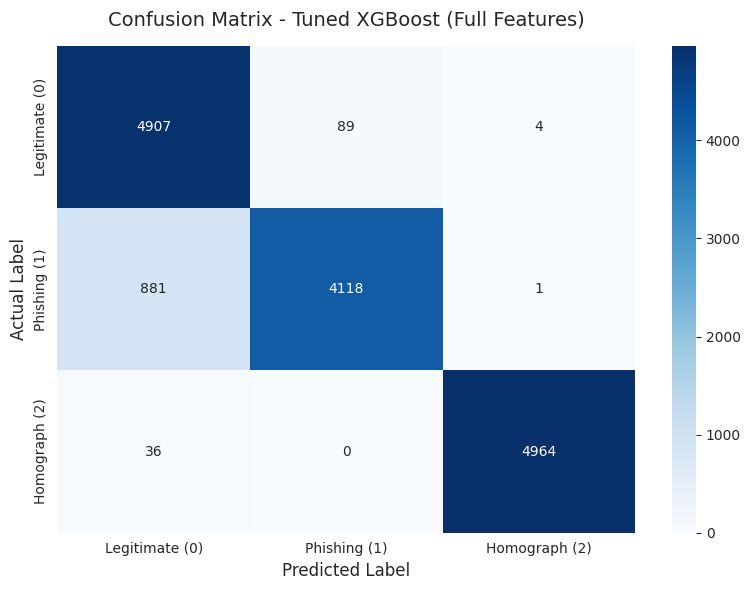

/tmp/ipykernel_727/3057608904.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


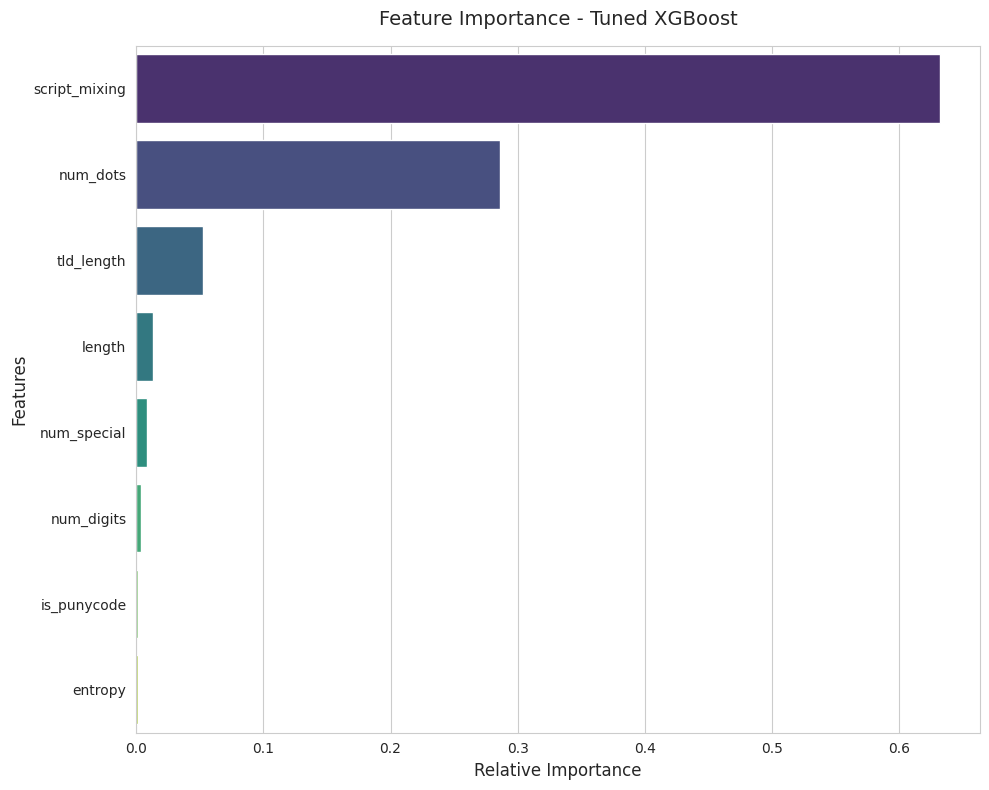

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 300, 'depth': 10}
Best Score: 0.9368549298391265
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Params: {'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 300, 'depth': 10}
Best Score: 0.9368549298391265


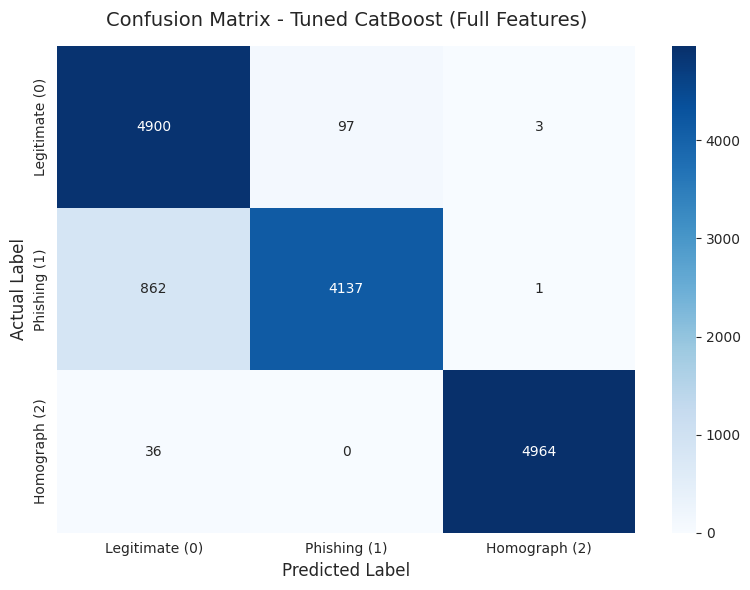

/tmp/ipykernel_727/3057608904.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


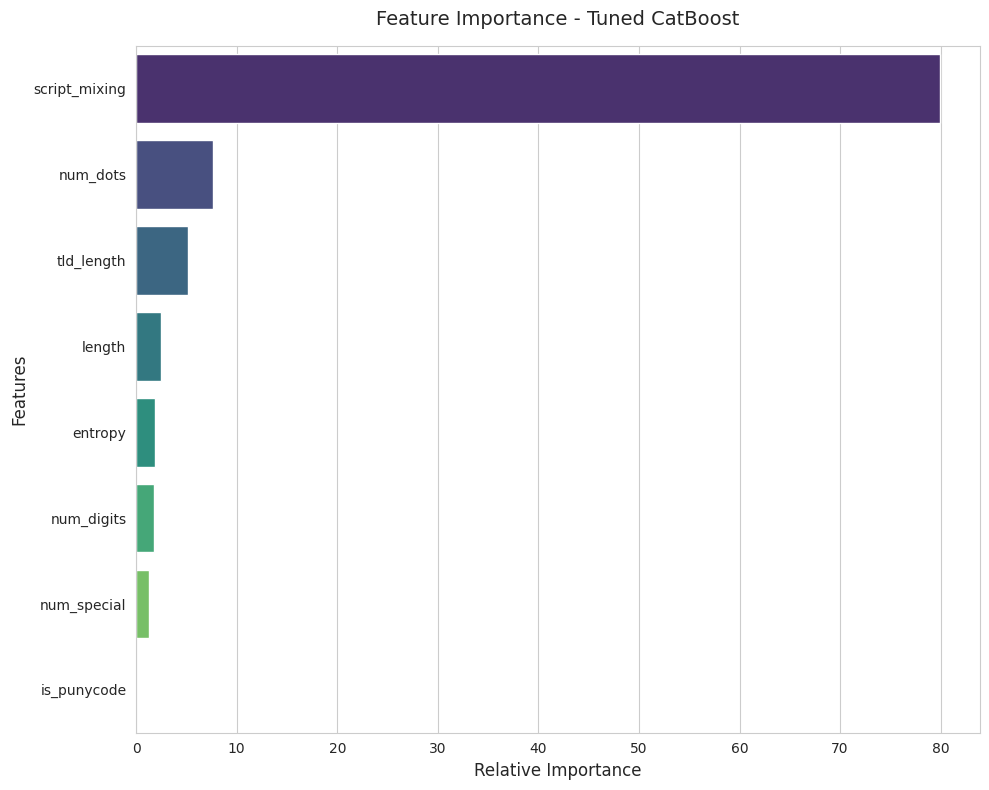

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression (Hash)-No tuning,0.57980,0.57319,0.57980,0.57620
1,Random Forest (Hash)-No tuning,0.60213,0.62832,0.60213,0.61255
2,XGBoost (Hash)-No tuning,0.60753,0.63304,0.60753,0.61780
3,CatBoost (Hash)-No tuning,0.59620,0.61831,0.59620,0.60540
4,Logistic Regression (Basic Features)-No tuning,0.58493,0.58184,0.58493,0.57622
5,Random Forest (Basic Features)-No tuning,0.57080,0.59548,0.57080,0.58066
6,XGBoost (Basic Features)-No tuning,0.58140,0.60132,0.58140,0.57922
7,CatBoost (Basic Features)-No tuning,0.58253,0.60487,0.58253,0.59004
8,Logistic Regression (Full Features)-No tuning,0.91767,0.91899,0.91767,0.91776
9,Random Forest (Full Features)-No tuning,0.92833,0.93351,0.92833,0.92821


In [ ]:
# 1. Logistic Regression
param_lr_full = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}
run_model(LogisticRegression(max_iter=1000), "Logistic Regression (Full Features)",
          X_train, y_train, X_test, y_test, results,
          param_grid=param_lr_full, tuning=True)

# 2. Random Forest
param_rf_full = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
run_model(RandomForestClassifier(), "Random Forest (Full Features)",
          X_train, y_train, X_test, y_test, results,
          param_grid=param_rf_full, tuning=True)

# 3. XGBoost
param_xgb_full = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}
run_model(XGBClassifier(use_label_encoder=False, eval_metrics='mlogloss'), "XGBoost (Full Features)",
          X_train, y_train, X_test, y_test, results,
          param_grid=param_xgb_full, tuning=True)

best_xgb_model, y_pred_xgb = run_model(
    XGBClassifier(use_label_encoder=False, eval_metrics='mlogloss'), "XGBoost (Full Features)",
    X_train, y_train, X_test, y_test, results,
    param_grid=param_xgb_full, tuning=True
)
plot_confusion_matrix(y_test, y_pred_xgb, title="Confusion Matrix - Tuned XGBoost (Full Features)")
plot_feature_importance(best_xgb_model, X_train.columns, title="Feature Importance - Tuned XGBoost")

# 4. CatBoost
param_cb_full = {
    'iterations': [200, 300, 400],
    'depth': [6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}
best_cb_model, y_pred_cb = run_model(
    CatBoostClassifier(verbose=0), "CatBoost (Full Features)",
    X_train, y_train, X_test, y_test, results,
    param_grid=param_cb_full, tuning=True
)

run_model(CatBoostClassifier(verbose=0), "CatBoost (Full Features)",
          X_train, y_train, X_test, y_test, results,
          param_grid=param_cb_full, tuning=True)
plot_confusion_matrix(y_test, y_pred_cb, title="Confusion Matrix - Tuned CatBoost (Full Features)")
plot_feature_importance(best_cb_model, X_train.columns, title="Feature Importance - Tuned CatBoost")

result_df = pd.DataFrame(results)
result_df

# 8. Evaluation

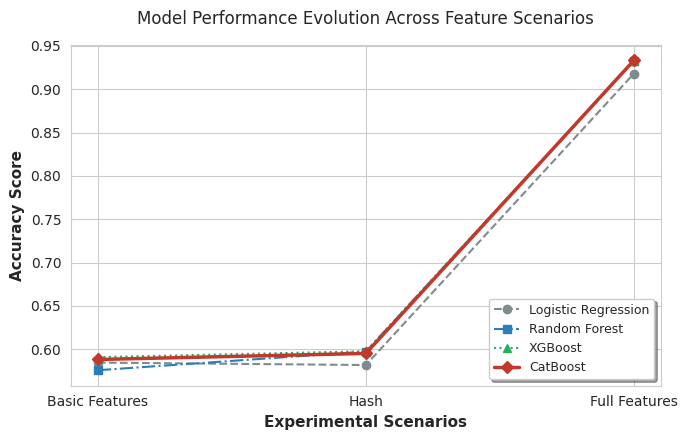

In [ ]:
df_clean = result_df.drop_duplicates(subset=['Model'])

def get_accuracy(algorithm, scenario):
    target_name = f"{algorithm} ({scenario})-Tuned"

    match = df_clean[df_clean['Model'] == target_name]
    if not match.empty:
        return match['Accuracy'].values[0]
    else:
        print(f"Warning: {target_name} not found in dataframe!")
        return 0.0

scenarios_df_names = ['Basic Features', 'Hash', 'Full Features']
scenarios_plot_labels = ['Basic Features', 'Hash', 'Full Features']

lr_acc = [get_accuracy("Logistic Regression", s) for s in scenarios_df_names]
rf_acc = [get_accuracy("Random Forest", s) for s in scenarios_df_names]
xgb_acc = [get_accuracy("XGBoost", s) for s in scenarios_df_names]
cb_acc = [get_accuracy("CatBoost", s) for s in scenarios_df_names]

sns.set_style("whitegrid")
plt.figure(figsize=(7, 4.5))

plt.plot(scenarios_plot_labels, lr_acc, marker='o', linestyle='--', color='#7f8c8d', label='Logistic Regression')
plt.plot(scenarios_plot_labels, rf_acc, marker='s', linestyle='-.', color='#2980b9', label='Random Forest')
plt.plot(scenarios_plot_labels, xgb_acc, marker='^', linestyle=':', color='#27ae60', label='XGBoost')
plt.plot(scenarios_plot_labels, cb_acc, marker='D', linestyle='-', color='#c0392b', linewidth=2.5, label='CatBoost')

plt.ylabel('Accuracy Score', fontsize=11, fontweight='bold')
plt.xlabel('Experimental Scenarios', fontsize=11, fontweight='bold')
plt.title('Model Performance Evolution Across Feature Scenarios', fontsize=12, pad=15)
plt.legend(loc='lower right', fontsize=9, frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('scenario_evolution_dynamic.png', dpi=300)
plt.show()

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=result_df)

https://docs.google.com/spreadsheets/d/1jLYKYBvEOHmTCoiTUe-4eD8ETVEC2XmF7pRy-I9YVt4/edit#gid=0
